# Tahap 1: Data Preparation & Feature Engineering

**Permasalahan Pokok:**
Dataset mentah dari Transfermarkt berukuran sangat besar, mengandung pemain historis (pensiun), dan riwayat pertandingan yang terpencar di ratusan ribu baris. Memasukkan data mentah ini secara langsung ke algoritma akan menyebabkan tingginya *noise* dan inefisiensi komputasi.

**Langkah Penyelesaian:**
1. **Data Scoping:** Melakukan *filtering* untuk membuang pemain lawas. Hanya populasi pemain aktif (musim 2024 ke atas) yang dipertahankan agar model mampu menangkap inflasi bursa transfer sepak bola modern.
2. **Data Aggregation:** Meringkas tabel `appearances` menjadi agregasi statistik tunggal (total menit bermain, gol, dan assist) per `player_id`.
3. **Data Integration:** Menyatukan profil pemain, statistik agregat, dan membuang baris yang tidak memiliki label target (`market_value_in_eur`).
4. **Feature Engineering:** Mengonversi statistik kumulatif menjadi rasio per-90-menit (`goals_per_90` & `assists_per_90`) untuk menghasilkan metrik performa yang lebih objektif dan menetralkan bias pemain cadangan.

**Output Akhir (Artifact):**
Satu *file* utuh (`mercato_engineered_data.csv`) berisi 18.344 baris data matang yang telah terintegrasi dengan variabel target.

In [1]:
import pandas as pd
import os

# --- FASE 0: LOAD DATA ---
# (Ini bagian yang hilang dari notebook Anda)
df_players = pd.read_csv('../data/raw/players.csv')
df_valuations = pd.read_csv('../data/raw/player_valuations.csv')
df_appearances = pd.read_csv('../data/raw/appearances.csv')


# --- FASE 1: SCOPING & AGREGASI ---
df_modern_players = df_players[df_players['last_season'] >= 2024].copy()

df_stats_summary = df_appearances.groupby('player_id').agg(
    total_minutes=('minutes_played', 'sum'),
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum')
).reset_index()

df_merged = pd.merge(df_modern_players, df_stats_summary, on='player_id', how='left')
df_merged.fillna({'total_minutes': 0, 'total_goals': 0, 'total_assists': 0}, inplace=True)


# --- FASE 2: PENYESUAIAN TARGET VARIABLE ---
df_master = df_merged.copy()
df_master = df_master.dropna(subset=['market_value_in_eur'])


# --- FASE 3: FEATURE ENGINEERING (INOVASI) ---
df_master['minutes_played_safe'] = df_master['total_minutes'].replace(0, 1)
df_master['goals_per_90'] = (df_master['total_goals'] / df_master['minutes_played_safe']) * 90
df_master['assists_per_90'] = (df_master['total_assists'] / df_master['minutes_played_safe']) * 90

df_master['goals_per_90'] = df_master['goals_per_90'].round(2)
df_master['assists_per_90'] = df_master['assists_per_90'].round(2)
df_master = df_master.drop(columns=['minutes_played_safe'])


# --- FASE 4: EXPORT KE PROCESSED DATA ---
os.makedirs('../data/processed', exist_ok=True)
output_path = '../data/processed/mercato_engineered_data.csv'
df_master.to_csv(output_path, index=False)

print(f"✅ PROSES SELESAI. Dataset final berisi {len(df_master)} pemain modern siap digunakan.")
print(f"✅ File berhasil disimpan sebagai artifact di: {output_path}")

# Tampilkan hasil
df_master[['name', 'position', 'total_minutes', 'goals_per_90', 'assists_per_90', 'market_value_in_eur']].head()

✅ PROSES SELESAI. Dataset final berisi 18344 pemain modern siap digunakan.
✅ File berhasil disimpan sebagai artifact di: ../data/processed/mercato_engineered_data.csv


,name,position,total_minutes,goals_per_90,assists_per_90,market_value_in_eur
1,James Milner,Midfield,26708.0,0.13,0.24,750000.0
2,Óscar Ustari,Goalkeeper,630.0,0.00,0.00,600000.0
3,Anastasios Tsokanis,Midfield,21057.0,0.03,0.03,200000.0
4,Jonas Hofmann,Midfield,22111.0,0.28,0.34,2000000.0
5,Pepe Reina,Goalkeeper,31800.0,0.00,0.01,600000.0


# Tahap 2: Feature Selection (Analisis Korelasi)

**Tujuan Eksperimen:**
Mengatasi kelemahan dari jurnal referensi (Fatah dkk.) yang menggunakan pendekatan *brute-force* (memasukkan seluruh 40+ atribut mentah ke dalam model). Pendekatan tersebut memicu tingginya *noise* dan potensi *overfitting*.

**Metodologi:**
Pada tahap ini, kita menggunakan **Pearson Correlation Matrix** untuk mengukur kekuatan hubungan matematis antara setiap atribut independen terhadap variabel target (`market_value_in_eur`). 
* Nilai mendekati **1 atau -1** menunjukkan korelasi yang sangat kuat (Fitur Emas).
* Nilai mendekati **0** menunjukkan tidak ada korelasi (Fitur Noise yang harus dibuang).

Melalui analisis ini, kita akan mereduksi dimensi data secara objektif sebelum masuk ke tahap *Machine Learning modeling*.

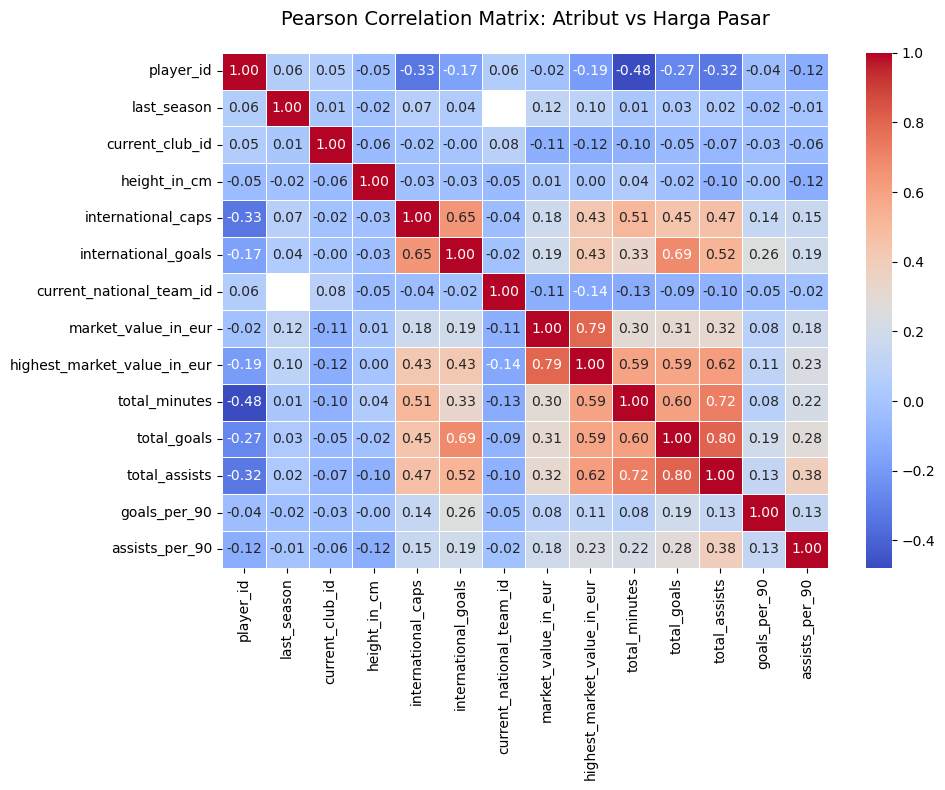

--- KEKUATAN KORELASI TERHADAP HARGA PASAR ---
market_value_in_eur            1.000000
highest_market_value_in_eur    0.794737
total_assists                  0.318028
total_goals                    0.309732
total_minutes                  0.296112
international_goals            0.189519
assists_per_90                 0.181754
international_caps             0.178995
last_season                    0.116933
goals_per_90                   0.082386
height_in_cm                   0.013650
player_id                     -0.021673
current_national_team_id      -0.111551
current_club_id               -0.113164
Name: market_value_in_eur, dtype: float64


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA PROCESSED

df = pd.read_csv('../data/processed/mercato_engineered_data.csv')

# 2. FILTER KOLOM NUMERIK

kolom_numerik = df.select_dtypes(include=['float64', 'int64'])

# 3. MENGHITUNG KORELASI (PEARSON)
korelasi = kolom_numerik.corr()

# 4. VISUALISASI HEATMAP
plt.figure(figsize=(10, 8))
plt.title('Pearson Correlation Matrix: Atribut vs Harga Pasar', fontsize=14, pad=20)

# Membuat visualisasi dengan Seaborn
sns.heatmap(korelasi, 
            annot=True,          
            cmap='coolwarm',    
            fmt='.2f',          
            linewidths=0.5)

plt.tight_layout()
plt.show()

# 5. MENAMPILKAN RANGKUMAN FOKUS PADA TARGET
print("--- KEKUATAN KORELASI TERHADAP HARGA PASAR ---")
korelasi_target = korelasi['market_value_in_eur'].sort_values(ascending=False)
print(korelasi_target)

# Tahap 3: Reduksi Dimensi & Pemisahan Data (Train-Test Split)

**Tujuan Eksperimen:**
Menindaklanjuti temuan dari Tahap 2 dengan mengeliminasi fitur-fitur *noise* (sampah) yang tidak memiliki signifikansi matematis terhadap variabel target. Setelah data bersih dari *noise*, dataset akan dipecah untuk mempersiapkan fase pelatihan (*training*) dan pengujian (*testing*) algoritma *Machine Learning*.

**Metodologi:**
1. **Data Reduction:** Menghapus kolom identifier unik (seperti `player_id`, `current_club_id`), atribut fisik yang terbukti tidak relevan (`height_in_cm`), dan data string/teks yang tidak bisa diproses oleh algoritma regresi standar pada iterasi pertama ini.
2. **Train-Test Split:** Membagi dataset final ke dalam dua bagian menggunakan rasio standar industri **80:20** (80% *Data Train*, 20% *Data Test*). Pemisahan ini sangat krusial untuk mencegah terjadinya *data leakage* (kebocoran data) dan memastikan model diuji secara objektif pada data yang belum pernah dilihat sebelumnya.

In [7]:
# --- FASE 3: SEGMENTASI DATA & TRAIN-TEST SPLIT (KASTA BAWAH) ---
import pandas as pd
from sklearn.model_selection import train_test_split

print("Fase 3: Mengeksekusi Feature Engineering & Segmentasi...")

# 1. Load Data
df = pd.read_csv('../data/processed/mercato_engineered_data.csv')

# 2. Ekstrak Umur
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['age'] = 2024 - df['date_of_birth'].dt.year
df['age'] = df['age'].fillna(df['age'].median())

# 3. Encoding Posisi
df_encoded = pd.get_dummies(df, columns=['position'], drop_first=False)
kolom_bool = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[kolom_bool] = df_encoded[kolom_bool].astype(int)

# 4. Buang Noise secara Presisi
kolom_dibuang = [
    'player_id', 'current_national_team_id', 'current_club_id', 
    'height_in_cm', 'name', 'first_name', 'last_name', 'last_season', 
    'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 
    'agent_name', 'image_url', 'url', 'current_club_name', 'sub_position', 
    'foot', 'contract_expiration_date', 'current_club_domestic_competition_id',
    'date_of_birth'
]
df_model = df_encoded.drop(columns=kolom_dibuang, errors='ignore')
df_model_final = df_model.select_dtypes(exclude=['object', 'string', 'datetime64[ns]'])

# =====================================================================
# 5. SEGMENTASI (The Gatekeeper)
# =====================================================================
# Mengisolasi HANYA pemain dengan rekor harga tertinggi <= €1.000.000
mask_bawah = df_model_final['highest_market_value_in_eur'] <= 1000000
df_bawah = df_model_final[mask_bawah]

print(f"Dataset berhasil dipangkas! Tersisa {df_bawah.shape[0]} baris khusus pemain kasta bawah/menengah.")

# 6. Pemisahan Input (X) dan Target (y)
X = df_bawah.drop(columns=['market_value_in_eur'])
y = df_bawah['market_value_in_eur']

# 7. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Fase 3 Selesai: Data siap diproses oleh Model Spesialis!")

Fase 3: Mengeksekusi Feature Engineering & Segmentasi...
Dataset berhasil dipangkas! Tersisa 9127 baris khusus pemain kasta bawah/menengah.
✅ Fase 3 Selesai: Data siap diproses oleh Model Spesialis!


# Tahap 4: Model Training & Evaluation (XGBoost)

**Tujuan Eksperimen:**
Melatih algoritma *Extreme Gradient Boosting* (XGBoost) menggunakan *Data Train* untuk mempelajari pola non-linear antara statistik performa pemain dan harga pasarnya. 

**Metodologi:**
Model dievaluasi menggunakan data yang belum pernah dilihat sebelumnya (*Data Test*) dengan metrik:
* **MAE (Mean Absolute Error):** Rata-rata selisih absolut tebakan model dengan harga asli.
* **RMSE (Root Mean Squared Error):** Memberikan penalti lebih besar pada tebakan yang meleset sangat jauh.
* **R2 Score:** Persentase variasi harga pasar yang berhasil dijelaskan oleh model (mendekati 1.0 berarti sangat akurat).

In [ ]:
# --- FASE 4: PELATIHAN MODEL & EVALUASI (SPESIALIS KASTA BAWAH) ---
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from IPython.display import display

print("Fase 4: Melatih XGBoost khusus untuk valuasi pemain kelas menengah-bawah...")

# 1. Inisialisasi Model
model_bawah = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# 2. Pelatihan (Training)
model_bawah.fit(X_train, y_train)
print("✅ Model berhasil dilatih!")

# 3. Prediksi pada Data Uji
y_pred = model_bawah.predict(X_test)

# 4. Evaluasi Kinerja
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- RAPOR KINERJA (MODEL KASTA BAWAH) ---")
print(f"Mean Absolute Error (MAE) : € {mae:,.2f}")
print(f"Root Mean Squared (RMSE)  : € {rmse:,.2f}")
print(f"R-squared (R2 Score)      : {r2:.4f}")

# 5. Komparasi Visual
df_comparison = pd.DataFrame({
    'Harga Asli (Real)': y_test.values,
    'Harga Tebakan (Prediksi)': y_pred,
    'Selisih (Error)': abs(y_test.values - y_pred)
})

pd.options.display.float_format = '€ {:,.0f}'.format
print("\n--- SAMPEL 10 TEBAKAN PERTAMA ---")
display(df_comparison.head(10))

Fase 4: Melatih XGBoost khusus untuk valuasi pemain kelas menengah-bawah...
✅ Model berhasil dilatih!

--- RAPOR KINERJA (MODEL KASTA BAWAH) ---
Mean Absolute Error (MAE) : € 82,142.89
Root Mean Squared (RMSE)  : € 124,621.06
R-squared (R2 Score)      : 0.7685

--- SAMPEL 10 TEBAKAN PERTAMA ---


,Harga Asli (Real),Harga Tebakan (Prediksi),Selisih (Error)
0,"€ 150,000","€ 190,157","€ 40,157"
1,"€ 750,000","€ 644,499","€ 105,501"
2,"€ 800,000","€ 725,361","€ 74,639"
3,"€ 50,000","€ 46,565","€ 3,435"
4,"€ 100,000","€ 100,586",€ 586
5,"€ 400,000","€ 413,226","€ 13,226"
6,"€ 150,000","€ 291,974","€ 141,974"
7,"€ 300,000","€ 366,520","€ 66,520"
8,"€ 250,000","€ 393,907","€ 143,907"
9,"€ 150,000","€ 463,636","€ 313,636"


Fse 5

Membongkar otak XGBoost untuk melihat prioritas keputusannya...


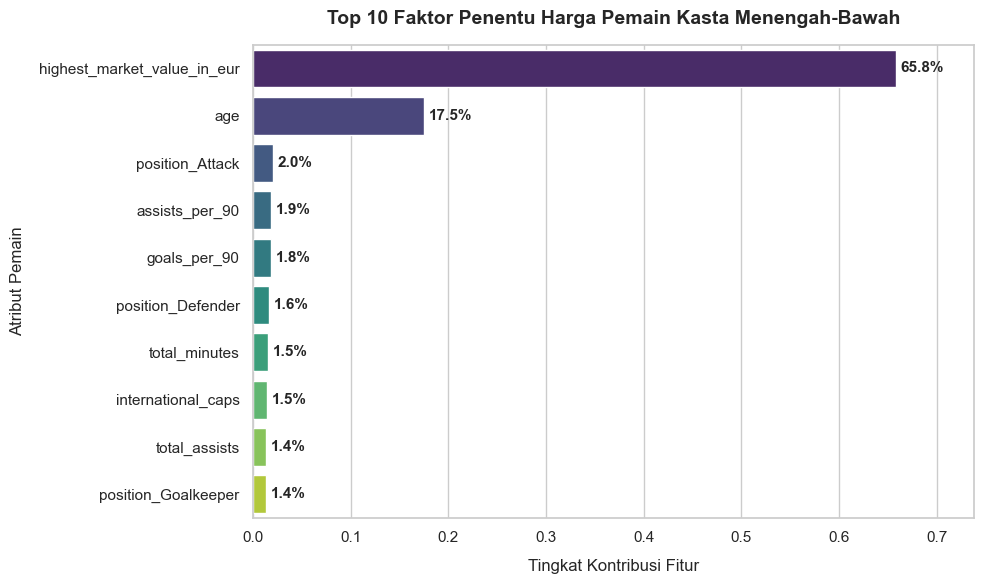

In [12]:
# --- FASE 5: MODEL EXPLAINABILITY (FEATURE IMPORTANCE) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Membongkar otak XGBoost untuk melihat prioritas keputusannya...")

# Ekstrak bobot fitur (Gain) dari model kasta bawah
importances = model_bawah.feature_importances_
fitur = X_train.columns

# Masukkan ke DataFrame dan ambil 10 teratas
df_importance = pd.DataFrame({'Fitur': fitur, 'Kontribusi': importances})
df_importance = df_importance.sort_values(by='Kontribusi', ascending=False).head(10)

# Visualisasi Gaya Publikasi Jurnal
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Membuat barplot horizontal
ax = sns.barplot(
    x='Kontribusi', 
    y='Fitur', 
    data=df_importance, 
    palette='viridis', 
    hue='Fitur', 
    legend=False
)

# Anotasi persentase di ujung balok
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height() / 2, f'{width:.1%}', 
             ha='left', va='center', fontsize=11, fontweight='bold')

plt.title('Top 10 Faktor Penentu Harga Pemain Kasta Menengah-Bawah', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tingkat Kontribusi Fitur', fontsize=12, labelpad=10)
plt.ylabel('Atribut Pemain', fontsize=12, labelpad=10)
plt.xlim(0, df_importance['Kontribusi'].max() + 0.08) 
plt.tight_layout()

plt.show()